# Heritage Twin MVP - Video to 3D Gaussian Splatting Model

Notebook này chạy pipeline prototype:

```text
Samsung/iPhone video
→ download từ Google Drive
→ extract + lọc frame
→ COLMAP qua convert.py
→ train Gaussian Splatting qua train.py
→ xuất model folder + .zip
```

Thiết kế cho Google Colab GPU T4. Với video 20-30 giây, 100-120 frame, 1080p, thời gian kỳ vọng khoảng **45-120 phút**.

> Lần đầu nên dùng một vật nhỏ có texture rõ, ánh sáng đều. Tránh cốc quá bóng, trong suốt, trắng trơn hoặc nền trắng trơn.

## 0. Hướng dẫn quay video

Khuyến nghị cho lần đầu:

- Resolution: **1080p**. Có thể quay 4K nhưng notebook sẽ resize frame về `MAX_FRAME_WIDTH`.
- FPS: **30 fps**.
- Thời lượng: **20-30 giây**.
- Cách quay: đi chậm quanh vật thể đúng 1 vòng, giữ khoảng cách 40-70 cm.
- Không zoom, không portrait mode, không flash.
- Khóa exposure/focus nếu điện thoại cho phép.
- Vật thể đứng yên, camera di chuyển quanh vật thể. Không quay kiểu đặt điện thoại cố định rồi xoay vật thể trên bàn xoay, vì nền đứng yên còn vật thể xoay có thể làm COLMAP lỗi.

In [ ]:
# =============================
# 1. CONFIG - chỉnh cell này
# =============================

SCENE_NAME = "pikachu"  # đổi thành tên scene của bạn, ví dụ: "cup", "statue", "mini_temple"

# Cách 1: dùng link Google Drive share public / anyone with link
# Ví dụ: https://drive.google.com/file/d/FILE_ID/view?usp=sharing
GDRIVE_URL = "https://drive.google.com/file/d/1rDQReG82d1ivA6BkDesSndsLW_HPZ46v/view?usp=sharing"  # DÁN LINK DRIVE VIDEO VÀO ĐÂY

# Cách 2: nếu đã mount Google Drive, dùng path trực tiếp, ví dụ:
# /content/drive/MyDrive/heritage_twin/cup.mp4
DRIVE_VIDEO_PATH = ""

# Frame extraction
TARGET_SAMPLE_FPS = 4          # 4 fps x 30s = khoảng 120 frame
MAX_FRAMES = 120               # giới hạn frame để COLMAP + train nhanh trên T4
MAX_FRAME_WIDTH = 1280         # 1280 ổn cho prototype; 1600 đẹp hơn nhưng lâu hơn
MIN_BLUR_SCORE = 60.0          # thấp quá giữ nhiều frame mờ; cao quá có thể loại quá nhiều frame
JPEG_QUALITY = 95

# Training
TRAIN_ITERS = 7000             # prototype: 7000. Đẹp hơn: 10000-15000. Không khuyên 30000 trên T4 lần đầu.
TRAIN_RESOLUTION = 1           # 1 = dùng frame đã resize. Có thể để 2 nếu bị out-of-memory.
USE_EXPOSURE_COMPENSATION = False  # bật sau nếu ảnh bị thay đổi sáng/tối nhiều; có thể không tương thích một số branch

# COLMAP
COLMAP_USE_GPU = True

# Paths
WORKDIR = "/content/heritage_twin_mvp"
REPO_DIR = f"{WORKDIR}/gaussian-splatting"
SCENE_DIR = f"{WORKDIR}/scenes/{SCENE_NAME}"
INPUT_DIR = f"{SCENE_DIR}/input"
MODEL_DIR = f"{WORKDIR}/outputs/{SCENE_NAME}_model"
VIDEO_PATH = f"{WORKDIR}/videos/{SCENE_NAME}.mp4"
ZIP_PATH = f"{WORKDIR}/outputs/{SCENE_NAME}_model.zip"

print("Scene:", SCENE_NAME)
print("Workdir:", WORKDIR)
print("Input frames:", INPUT_DIR)
print("Model output:", MODEL_DIR)

Scene: pikachu
Workdir: /content/heritage_twin_mvp
Input frames: /content/heritage_twin_mvp/scenes/pikachu/input
Model output: /content/heritage_twin_mvp/outputs/pikachu_model


In [ ]:
# =============================
# 2. Kiểm tra GPU
# =============================
!nvidia-smi

import torch, os, sys, subprocess, textwrap, json, shutil, pathlib, time
print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Fri Jul  3 10:25:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# =============================
# 3. Cài system packages
# =============================
# COLMAP phục vụ SfM; ffmpeg phục vụ video; imagemagick không bắt buộc nhưng convert.py có thể dùng nếu --resize.
!apt-get update -qq
!apt-get install -y -qq colmap ffmpeg imagemagick

!colmap -h | head -n 5
!ffmpeg -version | head -n 3

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%
Selecting previously unselected package fonts-droid-fallback.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../00-fonts-droid-fallback_1%3a6.0.1r16-1.1build1_all.deb ...
Unpacking fonts-droid-fallback (1:6.0.1r16-1.1build1) ...
Selecting previously unselected package libfftw3-double3:amd64.
Preparing to unpack .../01-libfftw3-double3_3.3.8-2ubuntu8_amd64.deb ...
Unpacking libfftw3-double3:amd64 (3.3.8-2ubuntu8) ...
Selecting previously unselected package liblqr-1-0:amd64.
Preparing to unpack .../02-liblqr-1-0_0.4.2-2.1_amd64.deb ...
Unpacking liblqr-1-0:amd64 (0.4.2-2.1) ...
Selecting previously unselected package imagemagick-6-common.
Preparing to unpack .../03-imagemagick-6-common_8%3a6.9.11.60+dfsg-1.3ubuntu0.

In [ ]:
# =============================
# 4. Clone repo + cài Python/CUDA extensions
# =============================
import os, subprocess, sys, textwrap, pathlib, shutil
os.makedirs(WORKDIR, exist_ok=True)

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/graphdeco-inria/gaussian-splatting --recursive {REPO_DIR}
else:
    print("Repo already exists:", REPO_DIR)

%cd {REPO_DIR}

# Dependencies cơ bản
!pip install -q plyfile tqdm opencv-python gdown ninja

# Build CUDA extensions. Nếu cell này lỗi, Runtime > Restart runtime rồi chạy lại từ đầu.
# Trên Colab T4, bước này thường mất 3-8 phút.
!pip install -q ./submodules/diff-gaussian-rasterization
!pip install -q ./submodules/simple-knn

print("Install done")

Cloning into '/content/heritage_twin_mvp/gaussian-splatting'...
remote: Enumerating objects: 1053, done.
remote: Total 1053 (delta 0), reused 0 (delta 0), pack-reused 1053 (from 1)
Receiving objects: 100% (1053/1053), 78.71 MiB | 31.11 MiB/s, done.
Resolving deltas: 100% (595/595), done.
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core.git) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization.git) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/fused-ssim' (https://github.com/rahul-goel/fused-ssim.git) registered for path 'submodules/fused-ssim'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/heritage_twin_mvp/gaussian-splatting/SIBR_viewers'...
remote: Enumerating objects: 3293, done.        
remote: Counting objects: 100% (322/322), done. 

In [ ]:
# =============================
# 5. Download/copy video từ Google Drive
# =============================
from pathlib import Path
import os, shutil, subprocess, textwrap

Path(f"{WORKDIR}/videos").mkdir(parents=True, exist_ok=True)
Path(INPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(f"{WORKDIR}/outputs").mkdir(parents=True, exist_ok=True)

if GDRIVE_URL.strip():
    import gdown
    print("Downloading from Google Drive URL...")
    gdown.download(GDRIVE_URL, VIDEO_PATH, quiet=False, fuzzy=True)
elif DRIVE_VIDEO_PATH.strip():
    print("Copying video from mounted Drive path...")
    assert os.path.exists(DRIVE_VIDEO_PATH), f"Không thấy file: {DRIVE_VIDEO_PATH}"
    shutil.copy(DRIVE_VIDEO_PATH, VIDEO_PATH)
else:
    raise ValueError("Bạn cần điền GDRIVE_URL hoặc DRIVE_VIDEO_PATH trong cell CONFIG.")

assert os.path.exists(VIDEO_PATH), "Download/copy video thất bại."
print("Video saved to:", VIDEO_PATH)
print("Size MB:", os.path.getsize(VIDEO_PATH) / 1024 / 1024)

Downloading...
From: https://drive.google.com/uc?id=1rDQReG82d1ivA6BkDesSndsLW_HPZ46v
To: /content/heritage_twin_mvp/videos/pikachu.mp4
100%|██████████| 14.1M/14.1M [00:00<00:00, 32.5MB/s]

Video saved to: /content/heritage_twin_mvp/videos/pikachu.mp4
Size MB: 13.43181324005127


In [ ]:
# =============================
# 6. Extract frame + lọc frame mờ + resize
# =============================
import cv2, os, math, shutil, numpy as np
from pathlib import Path
from PIL import Image

# Clean input frames cũ nếu rerun
if os.path.exists(INPUT_DIR):
    shutil.rmtree(INPUT_DIR)
Path(INPUT_DIR).mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Không mở được video: {VIDEO_PATH}")

video_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total_frames / video_fps if video_fps else 0
step = max(1, round(video_fps / TARGET_SAMPLE_FPS))

print(f"Video FPS: {video_fps:.2f}")
print(f"Total frames: {total_frames}")
print(f"Duration: {duration:.2f}s")
print(f"Sampling every {step} frames ≈ {video_fps/step:.2f} fps")

candidates = []
frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    if frame_idx % step == 0:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
        candidates.append((frame_idx, blur_score, frame.copy()))
    frame_idx += 1
cap.release()

print("Candidate sampled frames:", len(candidates))
if not candidates:
    raise RuntimeError("Không extract được frame nào.")

# Ưu tiên frame đủ sắc nét; nếu quá ít thì fallback lấy top blur_score
sharp = [x for x in candidates if x[1] >= MIN_BLUR_SCORE]
if len(sharp) < min(40, MAX_FRAMES // 2):
    print(f"WARNING: Chỉ có {len(sharp)} frame vượt blur threshold {MIN_BLUR_SCORE}. Fallback dùng top frame theo sharpness.")
    candidates_sorted = sorted(candidates, key=lambda x: x[1], reverse=True)
    keep_pool = sorted(candidates_sorted[:max(40, min(len(candidates_sorted), MAX_FRAMES*2))], key=lambda x: x[0])
else:
    keep_pool = sharp

# Giữ phân bố đều theo thời gian, tránh chỉ lấy frame sắc nhất ở một đoạn
if len(keep_pool) > MAX_FRAMES:
    idxs = np.linspace(0, len(keep_pool)-1, MAX_FRAMES).round().astype(int)
    selected = [keep_pool[i] for i in idxs]
else:
    selected = keep_pool

print("Selected frames:", len(selected))
print("Blur score: min/mean/max =",
      f"{min(x[1] for x in selected):.1f}",
      f"{np.mean([x[1] for x in selected]):.1f}",
      f"{max(x[1] for x in selected):.1f}")

# Save frames as JPG. Resize nếu width quá lớn.
for out_i, (src_idx, blur, frame_bgr) in enumerate(selected):
    h, w = frame_bgr.shape[:2]
    if w > MAX_FRAME_WIDTH:
        scale = MAX_FRAME_WIDTH / w
        new_w = MAX_FRAME_WIDTH
        new_h = int(round(h * scale))
        frame_bgr = cv2.resize(frame_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    out_path = f"{INPUT_DIR}/frame_{out_i:04d}.jpg"
    cv2.imwrite(out_path, frame_bgr, [int(cv2.IMWRITE_JPEG_QUALITY), JPEG_QUALITY])

print("Saved frames to:", INPUT_DIR)
print("Frame count:", len(os.listdir(INPUT_DIR)))

Video FPS: 29.96
Total frames: 1568
Duration: 52.33s
Sampling every 7 frames ≈ 4.28 fps
Candidate sampled frames: 224
Selected frames: 120
Blur score: min/mean/max = 4.7 15.3 35.4
Saved frames to: /content/heritage_twin_mvp/scenes/pikachu/input
Frame count: 120


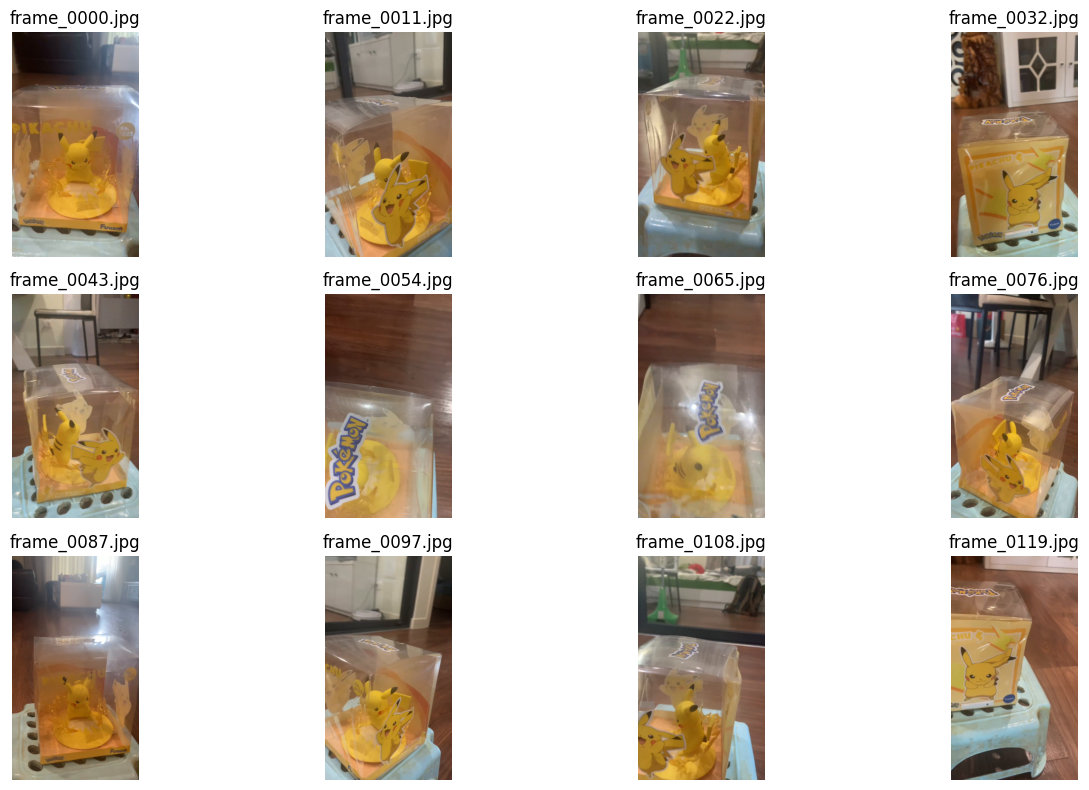

In [ ]:
# =============================
# 7. Preview một số frame
# =============================
import os, glob, math
from PIL import Image
import matplotlib.pyplot as plt

imgs = sorted(glob.glob(f"{INPUT_DIR}/*.jpg"))
assert imgs, "Chưa có ảnh trong input."

sample = [imgs[i] for i in np.linspace(0, len(imgs)-1, min(12, len(imgs))).round().astype(int)]
plt.figure(figsize=(14, 8))
for i, p in enumerate(sample):
    im = Image.open(p)
    plt.subplot(3, 4, i+1)
    plt.imshow(im)
    plt.axis('off')
    plt.title(os.path.basename(p))
plt.tight_layout()
plt.show()

In [ ]:
# Cell 8 - Run COLMAP conversion with realtime logs

import os
import sys
import time
import shutil
import subprocess
from pathlib import Path

REPO_DIR = "/content/heritage_twin_mvp/gaussian-splatting"
SCENE_DIR = "/content/heritage_twin_mvp/scenes/pikachu"

CLEAN_COLMAP_OUTPUTS = True   # True = xóa output COLMAP cũ rồi chạy lại sạch
USE_XVFB = True               # Fix COLMAP/OpenGL/Qt on Colab
CAMERA_MODEL = "OPENCV"       # keep OPENCV for phone video frames

os.chdir(REPO_DIR)

print("Repo dir:", REPO_DIR)
print("Scene dir:", SCENE_DIR)
print("Input frames:", len(list(Path(SCENE_DIR, "input").glob("*"))))

# Clean old / interrupted COLMAP outputs
if CLEAN_COLMAP_OUTPUTS:
    for name in ["distorted", "sparse", "database.db", "stereo"]:
        path = Path(SCENE_DIR) / name
        if path.is_dir():
            shutil.rmtree(path)
            print("Removed dir:", path)
        elif path.is_file():
            path.unlink()
            print("Removed file:", path)

# Environment cleanup
env = os.environ.copy()
env.pop("QT_QPA_PLATFORM_PLUGIN_PATH", None)
env.pop("QT_PLUGIN_PATH", None)
env["DISPLAY"] = ":99"
env["XDG_RUNTIME_DIR"] = "/tmp/runtime-root"
Path(env["XDG_RUNTIME_DIR"]).mkdir(parents=True, exist_ok=True)

base_cmd = [
    "python", "-u", "convert.py",
    "-s", SCENE_DIR,
    "--camera", CAMERA_MODEL
]

if USE_XVFB:
    cmd = [
        "xvfb-run",
        "-a",
        "-s", "-screen 0 1280x1024x24",
    ] + base_cmd
else:
    cmd = base_cmd

print("\nRunning command:")
print(" ".join(cmd))
print("\n===== COLMAP / convert.py realtime log =====\n")

start = time.time()

process = subprocess.Popen(
    cmd,
    cwd=REPO_DIR,
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

try:
    for line in process.stdout:
        print(line, end="")
        sys.stdout.flush()
except KeyboardInterrupt:
    print("\nInterrupted by user. Terminating process...")
    process.terminate()
    try:
        process.wait(timeout=10)
    except subprocess.TimeoutExpired:
        process.kill()
    raise

ret = process.wait()
elapsed = time.time() - start

print("\n===== convert.py finished =====")
print(f"Return code: {ret}")
print(f"Elapsed: {elapsed/60:.1f} minutes")

if ret != 0:
    raise RuntimeError(f"convert.py failed with return code {ret}")

required = [
    Path(SCENE_DIR) / "sparse/0/cameras.bin",
    Path(SCENE_DIR) / "sparse/0/images.bin",
    Path(SCENE_DIR) / "sparse/0/points3D.bin",
]

print("\nChecking required sparse files:")
for p in required:
    print(p, "OK" if p.exists() else "MISSING")

if not all(p.exists() for p in required):
    raise RuntimeError("COLMAP/convert.py chưa tạo đủ sparse model.")

print("\nCOLMAP conversion done.")

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  => Completed observations: 1
  => Merged observations: 0
  => Retriangulated observations: 0

Global bundle adjustment

iter      cost      cost_change  |gradient|   |step|    tr_ratio  tr_radius  ls_iter  iter_time  total_time
   0  1.137430e+04    0.00e+00    3.93e+03   0.00e+00   0.00e+00  1.00e+04        0    6.81e-02    1.45e-01
   1  1.134554e+04    2.88e+01    3.88e+02   2.02e+00   9.99e-01  3.00e+04        1    1.52e-01    2.97e-01
   2  1.134472e+04    8.14e-01    1.84e+03   3.51e+00   9.92e-01  9.00e+04        1    1.80e-01    4.78e-01
   3  1.134417e+04    5.50e-01    3.09e+03   5.81e+00   9.81e-01  2.70e+05        1    1.52e-01    6.30e-01
   4  1.134393e+04    2.42e-01    1.98e+03   5.95e+00   9.76e-01  8.10e+05        1    1.34e-01    7.64e-01
   5  1.134390e+04    3.58e-02    3.10e+02   2.70e+00   9.99e-01  2.43e+06        1    1.30e-01    8.94e-01


Bundle adjustment report
------------------------
    Residuals

In [ ]:
import shutil
from google.colab import files

SCENE_DIR = "/content/heritage_twin_mvp/scenes/pikachu"

zip_path = shutil.make_archive(
    "/content/pikachu_colmap",
    "zip",
    SCENE_DIR
)

print(zip_path)

files.download(zip_path)

/content/pikachu_colmap.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>